In [12]:
import pandas as pd
import numpy as np
from modAL.models import ActiveLearner
from sklearn.model_selection import train_test_split

from tensorflow import keras
from tensorflow.keras.optimizers import *
from tensorflow.keras.models import Model, Sequential, load_model
from tensorflow.keras.layers import Input, Activation, AveragePooling2D, Conv2DTranspose, ZeroPadding2D
from tensorflow.keras.layers import Dense , Dropout, Conv2D ,Flatten, Conv1D, BatchNormalization
from sklearn.metrics import mean_squared_error

from matplotlib import pyplot as plt
import seaborn as sns
import copy

font_size = 18

In [3]:
# load numpy raw data
with open('all_ae.npy', 'rb') as f:
    h2_ae = np.load(f)
    Pos = np.load(f)

h2_ae_shape = h2_ae.shape
h2_ae_1dcnn = h2_ae.reshape(h2_ae_shape[0], h2_ae_shape[1], -1)
h2_ae.shape, Pos.shape

((4979, 56, 37, 32), (4979, 3))

In [101]:
print("train-test splitting ae data...")
x_train_ae, x_test_ae, y_train_ae, y_test_ae = train_test_split(h2_ae, Pos, test_size=0.1, random_state=42)
x_train_ae_cnn, x_test_ae_cnn, y_train_ae_cnn, y_test_ae_cnn = train_test_split(h2_ae_1dcnn, Pos, test_size=0.1, random_state=42)

print("splitting training data and active learning pool...")
train_x_al, pool_x_al, train_y_al, pool_y_al = train_test_split(x_train_ae_cnn, y_train_ae_cnn, test_size=0.8, random_state=42)

h2_ae_shape = h2_ae.shape
h2_ae_1dcnn = h2_ae.reshape(h2_ae_shape[0], h2_ae_shape[1], -1)

train-test splitting ae data...
splitting training data and active learning pool...


In [7]:
print(f"Test samples: {len(y_test_ae_cnn)}, pool size: {len(pool_y_al)}")


Test samples: 498, pool size: 3585


In [9]:
def get_prediction_precision(regressor, x_test, y_test):
    y_pred = regressor.predict(x_test)
    mse = mean_squared_error(y_true=y_test, y_pred=y_pred)
    #print(f"current MSE: {mse}")
    return mse

def cnn_model1(input_shape, opt=Adam(1e-3), dropout_rate=0.2):
    model = Sequential()
    model.add(Conv1D(16, 16, input_shape=input_shape, activation='relu'))
    model.add(Conv1D(32, 16, activation='relu'))
    model.add(Conv1D(32, 16, activation='relu'))
    model.add(Flatten())
    model.add(BatchNormalization())
    model.add(Dense(512))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(Dense(256))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(Dense(128, activation='relu'))
    model.add(Dense(3))
    model.compile(loss='mean_squared_error', optimizer=opt)
    return model

print("constructing 1D-CNN model...")
lr = 5e-3
epochs = 50
decay_rate = lr / 50
model_ae = cnn_model1(train_x_al.shape[1:], opt=Adam(5e-3, decay=decay_rate))

constructing 1D-CNN model...


In [10]:
# 1. Fit on original training data
print(f"train_x_al:{train_x_al.shape}, train_y_al:{train_y_al.shape}")
model_ae.fit(train_x_al, train_y_al, epochs=1, validation_data=(
    x_test_ae_cnn, y_test_ae_cnn), verbose=1)
print(f"Initial round of training finished, MSE:{get_prediction_precision(model_ae, x_test_ae_cnn, y_test_ae_cnn)}")


train_x_al:(896, 56, 1184), train_y_al:(896, 3)
28/28 [==============================] - 2s 61ms/step - loss: 96417.9453 - val_loss: 270803.3438
Initial round of training finished, MSE:270803.30755262694
Begin active learning process...


In [58]:
dist_dict = np.load('dist_dict.npy')

In [60]:
dist_dict.shape

(3585, 3585)

In [56]:
# dist_dict = []
# for i in range(len(pool_x_al)):
#     _row = []
#     for j in range(len(pool_x_al)):
#         _row.append(distance(pool_x_al[i], pool_x_al[j]))
#     dist_dict.append(_row)
# dist_dict = np.array(dist_dict)
# with open('dist_dict.npy', 'wb') as f:
#     np.save(f, dist_dict)
# print("dist_dict saved!")

In [38]:
def random_sampling(classifier, X_pool):
    n_samples = len(X_pool)
    query_idx = np.random.choice(range(n_samples))
    return [query_idx], X_pool[query_idx]

def distance(p1, p2):
    return np.linalg.norm(p1 - p2)

xs, ys = [], []
xs_idx = []
dist_dict = np.load('dist_dict.npy')
def location_based_sampling(classifier, X_pool):
    if len(X_pool) == 0:
        return random_sampling(classifier, X_pool)
    
    distances = [sum([dist_dict[chosen_idx][cur_idx] for chosen_idx in xs_idx]) for cur_idx, x in enumerate(X_pool)]
    query_idx = distances.index(max(distances))
    return [query_idx], X_pool[query_idx]

In [97]:
yy = np.load("dist_dict_pretrain.npy")
yy

array([30046753.73828125, 32724768.578125  , 33490410.515625  , ...,
       25527097.83300781, 25236103.81689453, 44970586.03515625])

In [107]:
dist_dict_pretrain = list(np.load('dist_dict_pretrain.npy'))
dist_dict_pretrain.index(max(dist_dict_pretrain))

2036

In [64]:
# print("Begin active learning process...")
# n_queries = 1700
# mode = "lb"
# #queries_num = np.linspace(100, 3500, 35)
# mse_dict = {}
# all_chosen_samples = []
# mode_dict = {
#     "random": random_sampling,
#     "lb": location_based_sampling
# }
# print("Initialize active learner...")
# regressor = ActiveLearner(
#     estimator=model_ae,
#     query_strategy=mode_dict[mode],
#     X_training=train_x_al, y_training=train_y_al
# )
# print(f"active learning for {n_queries} epochs")


# i = 0

# pool_x_shape = pool_x_al.shape
# while i <= n_queries:
#     # get_prediction_precision(regressor, x_test_ae_cnn, y_test_ae_cnn)
#     query_idx, query_instance = regressor.query(pool_x_al)
#     _x, _y = pool_x_al[query_idx], pool_y_al[query_idx]
#     pool_x_al = np.delete(pool_x_al, query_idx, axis=0)
#     pool_y_al = np.delete(pool_y_al, query_idx, axis=0)
#     #print(f"_x:{_x}, _y:{_y}")
#     all_chosen_samples.append(_y)
#     xs.append(_x)
#     ys.append(_y)
#     xs_idx.append(query_idx[0])

#     if i % 50 == 0 and i > 0:
#         # batch mode AL teach
#         regressor_copy = copy.copy(regressor)
#         #regressor.teach(_chosen_x[0], _chosen_y[0], only_new=False)

#         # _model = copy.copy(model_ae)
#         #_new_x = np.concatenate([_new_x, _x])
#         #_new_y = np.concatenate([_new_y, _y])
#         xs_backup = xs.copy()
#         ys_backup = ys.copy()
#         xs_idx_backup = xs_idx.copy()
#         xs = np.array(xs)
#         ys = np.array(ys)
#         x_shape, y_shape = xs.shape, ys.shape
#         xs = xs.reshape(x_shape[0], -1, x_shape[-1])
#         ys = ys.reshape(y_shape[0], -1)
#         print(f"xs:{xs.shape}, ys:{ys.shape}")
#         regressor.teach(xs, ys, only_new=False)
#         #model_ae.fit(xs, ys, validation_data=(x_test_ae_cnn, y_test_ae_cnn), verbose=1)

#         # _model.fit(_new_x, _new_y, epochs=10, validation_data=(
#         #     x_test_ae_cnn, y_test_ae_cnn), verbose=1)
#         mse = get_prediction_precision(regressor, x_test_ae_cnn, y_test_ae_cnn)
#         #mse = get_prediction_precision(model_ae, x_test_ae_cnn, y_test_ae_cnn)

#         if i <= 300 and mse > 150000:
#             print(f"Encountered large MSE: {mse}")
#             i = i - 1
#             regressor = regressor_copy
#             xs = xs_backup
#             ys = ys_backup
#             xs_idx = xs_idx_backup
#             continue
#         elif i > 300 and mse > 40000:
#             print(f"Encountered large MSE: {mse}")
#             i = i - 1
#             regressor = regressor_copy
#             xs = xs_backup
#             ys = ys_backup
#             xs_idx = xs_idx_backup
#             continue

#         # y_pred = regressor.predict(x_test_ae_cnn)
#         # mse = mean_squared_error(y_true=y_test_ae_cnn, y_pred=y_pred)
#         mse_dict[i] = mse
#         print(f"Evaluating model at {i}th query...mse:{mse}")
#         xs, ys, xs_idx = [], [], []
#     i += 1

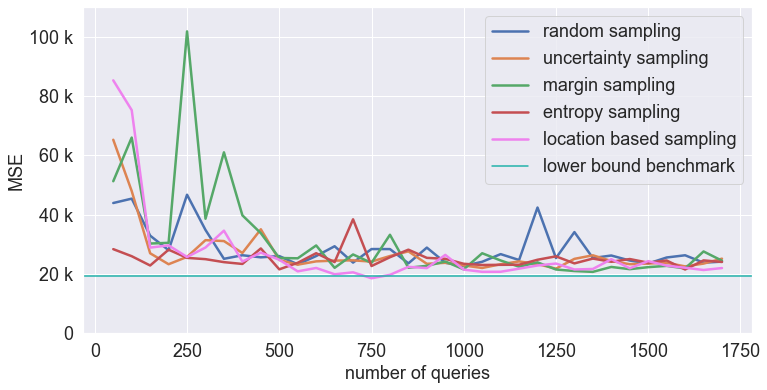

In [128]:
# after bootstrap
mse_dict_uncertainty_all = {50: 65274.10617262323, 100: 47983.413478226925, 150: 26983.203641819764, 200: 23294.31099955719, 250: 25767.44701760128, 300: 31415.140141454478, 350: 31105.991843989013, 400: 27092.073001079134, 450: 35079.79240952116, 500: 24737.2838222193, 550: 23151.96876497875, 600: 24261.26749647967, 650: 24512.062144447933, 700: 24604.692696459675, 750: 24176.277237716175, 800: 26059.26547327766, 850: 27632.748908348494, 900: 23435.436915971364, 950: 23772.73363501368, 1000: 22879.49065328263, 1050: 22032.062414307245, 1100: 23282.969981022256, 1150: 24243.42911624546, 1200: 23321.90422994128, 1250: 21807.755052372228, 1300: 25105.341141332796, 1350: 26304.221968649636, 1400: 24385.826748441923, 1450: 23298.717850202564, 1500: 23529.185271881477, 1550: 23792.64497272381, 1600: 22563.45969709588, 1650: 23508.140939580797, 1700: 25171.42693264304}
#mse_dict_random_all = {50: 71617.91123259407, 100: 76118.1079766072, 150: 26086.271611031905, 200: 25181.25968761669, 250: 25322.951496414305, 300: 44272.461741440486, 350:28398.824795304216, 400: 30680.718211711486, 450: 23913.075120752295, 500: 28074.190426629528, 550: 24939.382280740578, 600: 23736.4471744714, 650:22734.727656826475, 700: 24395.607630646726, 750: 25501.077709358007, 800: 25672.07353906204, 850: 28486.351716797435, 900: 32292.158496871547, 950:24151.577356446844, 1000: 23239.365246587506, 1050: 24791.677627518457, 1100: 25554.58103941589, 1150: 25686.368855251323, 1200: 25284.24356900402, 1250:25240.157766592307, 1300: 21225.440121947988, 1350: 23064.65967220269, 1400: 25142.367011513652, 1450: 23354.720628641415, 1500: 22440.945236014813, 1550:23349.91761343894, 1600: 24086.09442071166, 1650: 22419.511648289732, 1700: 21843.26741914726}
mse_dict_random_all = {50: 43938.65473272116, 100: 45414.48644163506, 150: 32936.1708191538, 200: 28020.95655935872, 250: 46733.35922744398, 300: 34855.51274405723, 350: 25121.05109737441, 400: 26326.092118955086, 450: 25623.495805314145, 500: 26046.956065929753, 550: 23262.249193148164, 600: 26053.763465327404, 650: 29358.360986277115, 700: 23846.1502608646, 750: 28413.213935541935, 800: 28401.46385156857, 850: 23584.242291479484, 900: 28901.89881011218, 950: 23808.375253824895, 1000: 22714.573657607438, 1050: 24120.740246977162, 1100: 26703.728214707702, 1150: 24717.33998396136, 1200: 42419.127575922765, 1250: 25372.907570312494, 1300: 34131.830719717196, 1350: 25395.34618173241, 1400: 26233.997076685435, 1450: 24542.40961228075, 1500: 23536.65718857488, 1550: 25567.64369904011, 1600: 26314.55865681308, 1650: 23815.499750545205, 1700: 24171.411069551297}

mse_dict_margin_all = {50: 51284.7889639079, 100: 66016.85194045343, 150: 30273.315947502284, 200: 30510.82017951523, 250: 101819.90187829953, 300: 38640.28536421815, 350: 61023.50973416321, 400: 39791.17053809991, 450: 33765.272898954434, 500: 25399.624299885418, 550: 25295.027473948994, 600: 29622.44115548955, 650: 22079.748127691277, 700: 26585.907866276033, 750: 23744.630069383275, 800: 33232.0238208386, 850: 22102.53742151872, 900: 22752.360947639696, 950: 24208.144510679806, 1000: 21562.274649640396, 1050: 26998.73762918318, 1100: 24560.675992117074, 1150: 22452.813376793336, 1200: 23929.085556499747, 1250: 21515.396521110073, 1300: 21002.850865800327, 1350: 20719.38535556257, 1400: 22377.759285214455, 1450: 21627.643168845763, 1500: 22310.4018052671, 1550: 22741.272950609113, 1600: 21881.32329409153, 1650: 27603.12559227485, 1700: 24481.910818201824}
mse_dict_entropy_all = {50: 28380.728995871905, 100: 25999.777289061687, 150: 22867.76505331373, 200: 28199.529204771632, 250: 25441.47017795502, 300: 25003.850975922735, 350: 23999.76663088189, 400: 23389.13185333071, 450: 28617.153615144096, 500: 21572.535891404164, 550: 23780.802876654794, 600: 27012.64679644414, 650: 24011.72121292667, 700: 38444.200770061805, 750: 22689.47333404826, 800: 25654.592084456395, 850: 28205.596121859, 900: 25440.040743286863, 950: 25117.27085514094, 1000: 23442.317186662574, 1050: 23036.608919064194, 1100: 23096.5961593425, 1150: 23124.530170379745, 1200: 24805.102946529525, 1250: 25953.39294655282, 1300: 23577.54266208186, 1350: 25200.517051388724, 1400: 24119.660713122023, 1450: 25046.87818086985, 1500: 23816.1011390917, 1550: 24551.050842369663, 1600: 21517.733642173673, 1650: 24585.92453574138, 1700: 24052.50585216122}
mse_dict_lb_all = {50: 85311.64716695521, 100: 75271.36831568436, 150: 28899.07103513311, 200: 29650.89521953306, 250: 25731.427636784156, 300: 28931.473862516348, 350: 34613.830631897516, 400: 24204.310671324285, 450: 27205.05839631966, 500: 24806.53228748342, 550: 20895.347891902882, 600: 22030.766707428153, 650: 19908.646176854752, 700: 20561.810297349202, 750: 18565.599819606814, 800: 19712.34558798008, 850: 22418.732593334615, 900: 21988.69912264359, 950: 26440.17127974246, 1000: 21483.179660251397, 1050: 20733.642465232584, 1100: 20752.89063393909, 1150: 21802.41866623738, 1200: 22873.944807215896, 1250: 23525.641730037347, 1300: 21523.249412622565, 1350: 21689.250708645926, 1400: 25001.588846352195, 1450: 21936.326068525017, 1500: 24345.00020680063, 1550: 22815.517135356367, 1600: 22114.225272985805, 1650: 21350.206114818156, 1700: 22003.772058103958}

n_queries = list(mse_dict_uncertainty_all.keys())
mses_random_all = list(mse_dict_random_all.values())
mses_uncertainty_all = list(mse_dict_uncertainty_all.values())
mses_margin_all = list(mse_dict_margin_all.values())
mses_entropy_all = list(mse_dict_entropy_all.values())
mses_lb_all = list(mse_dict_lb_all.values())


font_size = 18
line_width = 2.5
import matplotlib.ticker as ticker
sns.set()
fig, ax = plt.subplots(figsize=(12, 6))
#plt.figure(figsize=(12, 6))
plt.plot(n_queries, mses_random_all, label="random sampling", linewidth=line_width)
plt.plot(n_queries, mses_uncertainty_all, label="uncertainty sampling", linewidth=line_width)
plt.plot(n_queries, mses_margin_all, label="margin sampling", linewidth=line_width)
plt.plot(n_queries, mses_entropy_all, label="entropy sampling", linewidth=line_width)
plt.plot(n_queries, mses_lb_all, label="location based sampling", linewidth=line_width, color="violet")

y_bm = 19258.3560
plt.axhline(y=y_bm, color='lightseagreen', linestyle='-', label="lower bound benchmark")

plt.ylabel("MSE", fontsize=font_size)
plt.xlabel("number of queries", fontsize=font_size)
plt.legend(prop={'size': font_size})
plt.xticks(fontsize=font_size)
plt.yticks(fontsize=font_size)

plt.ylim((0, 110000))
ax.yaxis.set_major_formatter(ticker.EngFormatter())

Text(0.5, 0, 'MSE')

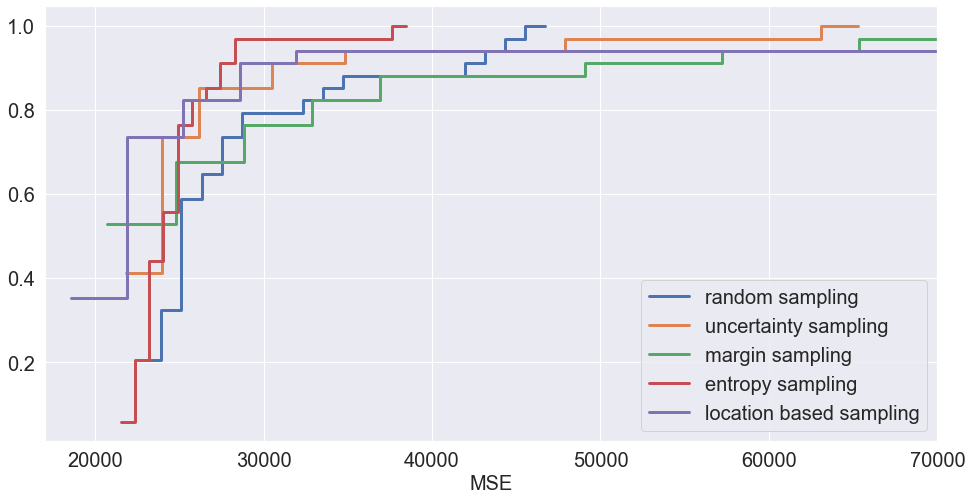

In [127]:
fig, ax = plt.subplots(figsize=(16, 8))
font_size = 20
line_width = 3
def plot_qs_cdf(qs_name, qs_var):
    counts, bins = np.histogram(qs_var, bins=20)
    cdf = np.cumsum(counts)/np.sum(counts)

    plt.plot(
        np.vstack((bins, np.roll(bins, -1))).T.flatten()[:-2],
        np.vstack((cdf, cdf)).T.flatten(), label=f"{qs_name} sampling",
        linewidth=line_width
    )

plot_qs_cdf("random", mses_random_all)
plot_qs_cdf("uncertainty", mses_uncertainty_all)
plot_qs_cdf("margin", mses_margin_all)
plot_qs_cdf("entropy", mses_entropy_all)
plot_qs_cdf("location based", mses_lb_all)

plt.xlim(17000, 70000)
plt.legend(loc="lower right", prop={'size': font_size})
plt.xticks(fontsize=font_size)
plt.yticks(fontsize=font_size)
plt.xlabel("MSE", fontsize=font_size)

In [121]:
min(mses_uncertainty_all), min(mses_lb_all)

(21807.755052372228, 18565.599819606814)

<AxesSubplot:xlabel='x', ylabel='y'>

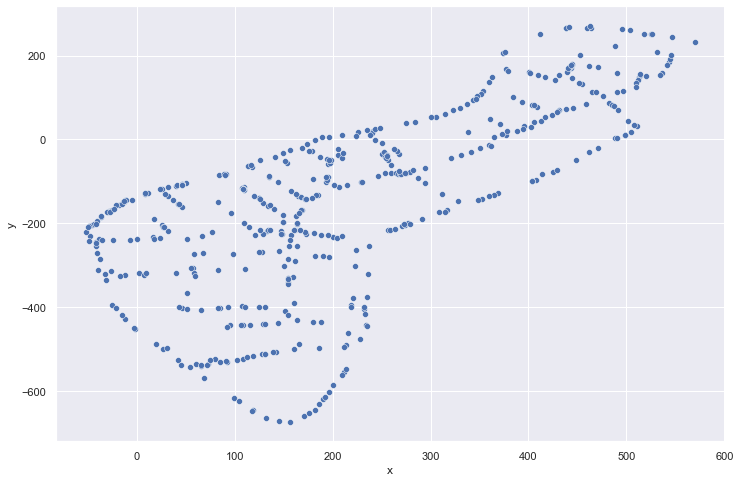

In [110]:
# Looking at the chosen samples by the random sampling method
df_chosen = pd.read_csv("chosen/cnn_ae_al1_lb_all_chosen_500iter.csv", index_col=0)
df_chosen["type"] = "chosen"
df_pool = pd.DataFrame(pool_y_al, columns=["x", "y", "z"])
df_pool["type"] = "overall pool"
df_concat = pd.concat([df_pool, df_chosen], ignore_index=True)
sns.set()
plt.figure(figsize=(12, 8))
sns.scatterplot(x="x", y="y", data=df_chosen)

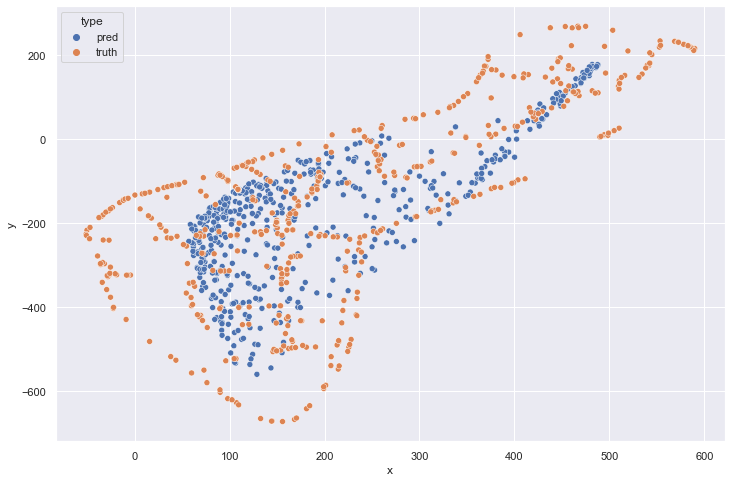

In [122]:
def analyze_predictions(y_test, x_test=None, file=None, model=None):
    if x_test is not None:
        preds = model.predict(x_test)
        preds = pd.DataFrame(preds, columns=["x", "y", "z"])
    else:
        preds = pd.read_csv(f"preds/{file}")
    preds = preds[["x", "y", "z"]]
    preds["type"] = "pred"
    truth = pd.DataFrame(y_test, columns=["x", "y", "z"])
    truth = truth[["x", "y", "z"]]
    truth["type"] = "truth"
    concat = pd.concat([preds, truth], ignore_index=True)
    sns.set()
    plt.figure(figsize=(12, 8))
    concat = concat[concat["x"]<1000]
    sns.scatterplot(x="x", y="y", data=concat, hue="type")
    
analyze_predictions(y_test_ae_cnn, file="cnn_ae_al1_lb_all_preds.csv")